In [1]:
from pathlib import Path
import xarray as xr
import ecco_v4_py as ecco
from xgcm import Grid
import matplotlib.pyplot as plt
import gsw
import cmocean
import numpy as np
import pandas as pd
import matplotlib.dates as mdates
import cartopy.crs as ccrs
from os.path import join,expanduser,exists,split
import glob

In [2]:
import warnings
warnings.filterwarnings("ignore")

#### **Load the desired variables and define grid/metrics**

In [3]:
ECCO_version = 'v4r4'
#ECCO_version = 'v4r5'

if ECCO_version == 'v4r4':
    # v4r4
    ECCO_dir = Path.home() / 'share_disk3/ECCO_products/Version4/Release4'
    grid_file_path = glob.glob(join(ECCO_dir,'*GEOMETRY*','*GEOMETRY*.nc'))[0]
    TS_file_paths           = join(ECCO_dir,'*TEMP_SALINITY*MONTHLY*',f'*.nc')
else: # by default
    ## v4r5
    ECCO_version = 'v4r5'
    ECCO_grid = Path.home() / 'share_disk3/ECCO_products/Version4/Release5/netcdf/native/grid/'
    ECCO_dir = Path.home() / 'share_disk3/ECCO_products/Version4/Release5/netcdf/native/monthly/'
    grid_file_path = glob.glob(join(ECCO_grid,'*GEOMETRY*.nc'))[0]
    TS_file_paths           = join(ECCO_dir,'*TEMPERATURE_SALINITY',f'*.nc')
print(ECCO_version)

v4r4


In [4]:
## Load the model grid
ecco_ds = xr.open_mfdataset(grid_file_path,\
                              chunks={'k':50,'tile':13,'j':90,'j_g':90,'i':90,'i_g':90})

In [5]:
# define the metrics
ecco_ds['drW'] = ecco_ds.hFacW * ecco_ds.drF #vertical cell size at u point
ecco_ds['drS'] = ecco_ds.hFacS * ecco_ds.drF #vertical cell size at v point
ecco_ds['drV'] = ecco_ds.rA * ecco_ds.drF # volume at centre and k
ecco_ds['drVg'] = ecco_ds.rAz * ecco_ds.drF # volume at q and k
ecco_ds['drVw'] = ecco_ds.rAw * ecco_ds.drF # volume at q and k
ecco_ds['drVs'] = ecco_ds.rAs * ecco_ds.drF # volume at q and k

metrics = { ('X',): ['dxC', 'dxG'], # X distances
    ('Y',): ['dyC', 'dyG'], # Y distances
    ('Z',): ['drW', 'drS', 'drC','drF'], # Z distances
    ('X', 'Y'): ['rA', 'rAz', 'rAs', 'rAw'], #Areas
    ('X', 'Y','Z'): ['drV','drVg','drVs','drVw']} #volumes

grid = Grid(ecco_ds,periodic=False, metrics=metrics)

### mask and volume

In [8]:
g = 9.81
rho0 = 1026

In [9]:
globmask = ecco_ds.hFacC.where(ecco_ds.hFacC==0,1)
total_volume = grid.integrate(globmask,['X','Y','Z']).sum('tile').compute()
centre_volume = grid.integrate(ecco_ds.Z*globmask ,['X','Y','Z']).sum('tile') / total_volume
profile_volume = grid.integrate(ecco_ds.hFacC,['X','Y']).sum('tile').compute()
local_depth = grid.integrate(globmask,['Z'])

In [8]:
H2 = grid.integrate(ecco_ds.maskC.where(ecco_ds.Z>-2000),'Z') #Integrating the maskC field over the vertical dimension Z
maskC_2000 = ecco_ds.maskC.where(ecco_ds.Z>-2000).where(H2==np.max(H2))
volume_2000 = grid.integrate(maskC_2000,['X','Y','Z']).sum('tile').compute()
surface_2000 = grid.integrate(ecco_ds.maskC.isel(k=0).where(H2==np.max(H2)),['X','Y']).sum('tile')

In [9]:
#Local stratification, squared bouyancy frequency N2
maskW = (grid.diff(ecco_ds.maskC.astype(float),'Z',to='outer',boundary='extend')+1)

alpha = grid.interp(gsw.alpha(ecco_ds.SALT,ecco_ds.THETA,ecco_ds.Z)*ecco_ds.maskC,'Z',to='outer',boundary='extend')
beta  = grid.interp(gsw.beta (ecco_ds.SALT,ecco_ds.THETA,ecco_ds.Z)*ecco_ds.maskC,'Z',to='outer',boundary='extend')
N2_T = grid.interp(-g*alpha*grid.derivative(ecco_ds.THETA,'Z',to='outer',boundary='extend')*maskW , 'Z') * ecco_ds.maskC     #Interpolate again to get back on center point Z
N2_S = grid.interp( g*beta *grid.derivative(ecco_ds.SALT ,'Z',to='outer',boundary='extend')*maskW , 'Z') * ecco_ds.maskC
N2   = N2_T + N2_S
N2 = N2.where(N2>1e-8,0)

#Computing the depth-averaged value of N2 for depths shallower than 2000 meters
N2_2k = (grid.integrate(N2*maskC_2000,['Z']) / H2).compute()

AttributeError: 'Dataset' object has no attribute 'SALT'

#### **Climatologies of N2 and DA**

In [22]:
ds = xr.open_dataset(f'trend_stratification_2k_ECCO{ECCO_version}.nc')
MEAN_N2_2k = ds.N2_2k.mean('time')
MEAN_dz_gb_2k = -ds.dz_gb_2k.mean('time')
N2_mean_2k = (grid.integrate(MEAN_N2_2k,['X','Y']).sum('tile') / surface_2000).compute().rename("N2_mean_2k")
dz_gb_mean_2k = (grid.integrate(MEAN_dz_gb_2k,['X','Y']).sum('tile') / surface_2000).compute().rename("N2_mean_2k")

In [23]:
def field_change(field, description = "", units = ""):
    
    new_grid_delta_lat = 1
    new_grid_delta_lon = 1

    new_grid_min_lat = -90
    new_grid_max_lat = 90

    new_grid_min_lon = -180
    new_grid_max_lon = 180

    new_grid_lon_centers, new_grid_lat_centers,\
    new_grid_lon_edges, new_grid_lat_edges,\
    field_nearest_1deg =\
            ecco.resample_to_latlon(ecco_ds.XC, \
                                    ecco_ds.YC, \
                                    field,\
                                    new_grid_min_lat, new_grid_max_lat, new_grid_delta_lat,\
                                    new_grid_min_lon, new_grid_max_lon, new_grid_delta_lon,\
                                    fill_value = np.nan, \
                                    mapping_method = 'nearest_neighbor',
                                    radius_of_influence = 120000)

    da = xr.DataArray(
        data=field_nearest_1deg,
        dims=["latitude", "longitude"],
        coords=dict(
            longitude=(["latitude","longitude"], new_grid_lon_centers),
            latitude=(["latitude","longitude"],  new_grid_lat_centers),
        ),
        attrs=dict(
            description=description,
            units=units,
        ),
    )

    return da

In [24]:
# --- Förbered data ---
# 1. D_COM
da1 = field_change(MEAN_dz_gb_2k, description="a) Local $D_{COM}$ 0–2000m", units="$D_{COM}\\ (m)$")
masked_da1 = da1.where((da1 > 0) & (da1 <= 0.75))

# 2. N²
da2 = field_change(MEAN_N2_2k*1e5, description="b) Mean $N^2$ 0–2000m", units="$\overline{N^{2}}\\ (10^{-5}\\ s^{-2})$")
masked_da2 = da2.where((da2 > 0) & (da2 <= 3.5))

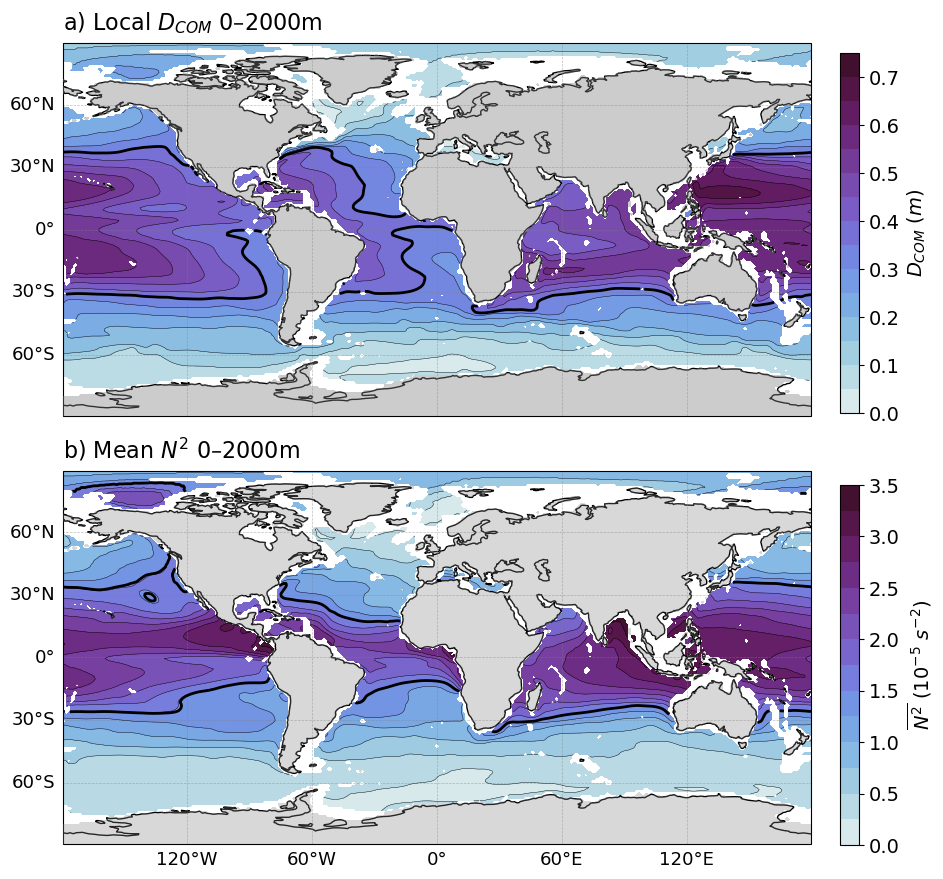

In [25]:
plt.rcParams['font.size'] = 14
fig, axes = plt.subplots(
    nrows=2, ncols=1,
    figsize=(13, 9),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

# ----------------------
# --- Subplot 1: D_COM
# ----------------------
ax1 = axes[0]
ax1.set_facecolor("white")
ax1.coastlines()
gl1 = ax1.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
gl1.right_labels = False
gl1.top_labels = False
gl1.bottom_labels = False
gl1.xlabel_style = {"size": 13}
gl1.ylabel_style = {"size": 13}

levels1 = np.linspace(0, 0.75, 16)
contour1 = ax1.contourf(
    da1.longitude, da1.latitude, masked_da1,
    levels=levels1,
    cmap="cmo.dense",
    extend="neither",
    transform=ccrs.PlateCarree()
)
ax1.contour(
    da1.longitude, da1.latitude, masked_da1,
    levels=levels1,
    colors="black",
    linewidths=0.3,
    transform=ccrs.PlateCarree()
)
ax1.contour(
    da1.longitude, da1.latitude, masked_da1,
    levels=[dz_gb_mean_2k.values],
    colors="black",
    linewidths=2,
    transform=ccrs.PlateCarree()
)
mask_nan1 = da1.isnull()
ax1.contourf(
    da1.longitude, da1.latitude, mask_nan1,
    levels=[0.5, 1.5],
    colors=["grey"],
    alpha=0.4,
    transform=ccrs.PlateCarree(),
    zorder=3
)
ax1.text(0.0, 1.02, da1.attrs["description"], fontsize=16, ha='left', va='bottom', transform=ax1.transAxes)

# Colorbar för subplot 1
cbar_ax1 = fig.add_axes([0.76, 0.53, 0.015, 0.40])  # [left, bottom, width, height]
plt.colorbar(contour1, cax=cbar_ax1, orientation="vertical", label=da1.attrs["units"])


# ----------------------
# --- Subplot 2: N²
# ----------------------
ax2 = axes[1]
ax2.set_facecolor("white")
ax2.coastlines()
gl2 = ax2.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
gl2.right_labels = False
gl2.top_labels = False
gl2.xlabel_style = {"size": 13}
gl2.ylabel_style = {"size": 13}

levels2 = np.linspace(0, 3.5, 15)
contour2 = ax2.contourf(
    da2.longitude, da2.latitude, masked_da2,
    levels=levels2,
    cmap="cmo.dense",
    extend="neither",
    transform=ccrs.PlateCarree()
)
ax2.contour(
    da2.longitude, da2.latitude, masked_da2,
    levels=levels2,
    colors="black",
    linewidths=0.3,
    transform=ccrs.PlateCarree()
)
ax2.contour(
    da2.longitude, da2.latitude, masked_da2,
    levels=[N2_mean_2k.values*1e5],
    colors="black",
    linewidths=2,
    transform=ccrs.PlateCarree()
)
mask_nan2 = da2.isnull()
ax2.contourf(
    da2.longitude, da2.latitude, mask_nan2,
    levels=[0.5, 1.5],
    colors=["grey"],
    alpha=0.3,
    transform=ccrs.PlateCarree(),
    zorder=3
)
ax2.text(0.0, 1.02, da2.attrs["description"], fontsize=16, ha='left', va='bottom', transform=ax2.transAxes)

# Colorbar för subplot 2
cbar_ax2 = fig.add_axes([0.76, 0.05, 0.015, 0.40])
plt.colorbar(contour2, cax=cbar_ax2, orientation="vertical", label=da2.attrs["units"])

# Justera layout så att den inte krockar med colorbars
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.savefig(f'Figure1_ECCO{ECCO_version}.png', bbox_inches='tight')
plt.savefig(f'Figure1_ECCO{ECCO_version}.pdf', bbox_inches='tight')
plt.show()